In [1]:
#import the things that we need
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import glob
import polars as pl

In [2]:
def get_gene_category(hmm_name):
    """Map gene names to their categories based on the provided grouping rules"""
    # Define gene categories
    gene_categories = {
        "Type I MTases": [
            "RM__Type_I_MTases_FAM_0",
            "RM__Type_I_MTases_FAM_1",
            "RM__Type_I_MTases_FAM_2",
            "RM__Type_I_MTases_FAM_3",
        ],
        
        "Type I REases": [
            "RM__Type_I_REases_FAM_0.einsi_trimmed",
            "RM__Type_I_REases_FAM_1.einsi_trimmed",
            "RM__Type_I_REases_FAM_2.einsi_trimmed",
        ],
        
        "Type I S": [
            "RM__Type_I_S_01",
            "RM__Type_I_S_02",
            "RM__Type_I_S_03",
            "RM__Type_I_S_04",
            "RM__Type_I_S_06",
            "RM__Type_I_S_51",
            "RM__Type_I_S_52",
        ],
        
        "Type II MTases": [
            "RM_Type_II__Type_II_MTases_FAM_0",
            "RM_Type_II__Type_II_MTases_FAM_1",
            "RM_Type_II__Type_II_MTases_FAM_2",
            "RM_Type_II__Type_II_MTases_FAM_3",
            "RM_Type_II__Type_II_MTases_FAM_4",
            "RM_Type_II__Type_II_MTases_FAM_5",
            "RM_Type_II__Type_II_MTases_FAM_6",
            "RM_Type_II__Type_II_MTases_FAM_7",
            "RM_Type_II__Type_II_MTases_FAM_8",
            "RM_Type_II__Type_II_MTases_FAM_9",
            "RM_Type_II__Type_II_MTases_FAM_10",
            "RM_Type_II__Type_II_MTases_FAM_11",
            "RM_Type_II__Type_II_MTases_FAM_12",
            "RM_Type_II__Type_II_MTases_FAM_13",
            "RM_Type_II__Type_II_MTases_FAM_14",
            "RM_Type_II__Type_II_MTases_FAM_15",
            "RM_Type_II__Type_II_MTases_FAM_16",
            "RM_Type_II__Type_II_MTases_FAM_17",
            "RM_Type_II__Type_II_MTases_FAM_18",
            "RM_Type_II__Type_II_MTases_FAM_19",
            "RM_Type_II__Type_II_MTases_FAM_20",
            "RM_Type_II__Type_II_MTases_FAM_21",
            "RM_Type_II__Type_II_MTases_FAM_22",
            "RM_Type_II__Type_II_MTases_FAM_23",
            "RM_Type_II__Type_II_MTases_FAM_24",
            "RM_Type_II__Type_II_MTases_FAM_25",
            "RM_Type_II__Type_II_MTases_FAM_26",
            "RM_Type_II__Type_II_MTases_FAM_27",
            "RM_Type_II__Type_II_MTases_FAM_28",
            "RM_Type_II__Type_II_MTases_FAM_29",
            "RM_Type_II__Type_II_MTases_FAM_30",
            "RM_Type_II__Type_II_MTases_FAM_31",
            "RM_Type_II__Type_II_MTases_FAM_32",
            "RM_Type_II__Type_II_MTases_FAM_33",
            "RM_Type_II__Type_II_MTases_FAM_34",
            "RM_Type_II__Type_II_MTases_FAM_35",
            "RM_Type_II__Type_II_MTases_FAM_36",
            "RM_Type_II__Type_II_MTases_FAM_37",
            "RM_Type_II__Type_II_MTases_FAM_38",
            "RM_Type_II__Type_II_MTases_FAM_39",
            "RM_Type_II__Type_II_MTases_FAM_40",
            "RM_Type_II__Type_II_MTases_FAM_41",
            "RM_Type_II__Type_II_MTases_FAM_42",
        ],
        
        "Type II REases": [
            "RM_Type_II__Type_II_REase01",
            "RM_Type_II__Type_II_REase02",
            "RM_Type_II__Type_II_REase03",
            "RM_Type_II__Type_II_REase04",
            "RM_Type_II__Type_II_REase05",
            "RM_Type_II__Type_II_REase06",
            "RM_Type_II__Type_II_REase07",
            "RM_Type_II__Type_II_REase08",
            "RM_Type_II__Type_II_REase09",
            "RM_Type_II__Type_II_REase10",
            "RM_Type_II__Type_II_REase11",
            "RM_Type_II__Type_II_REase12",
            "RM_Type_II__Type_II_REase13",
            "RM_Type_II__Type_II_REase14",
            "RM_Type_II__Type_II_REase15",
            "RM_Type_II__Type_II_REase16",
            "RM_Type_II__Type_II_REase17",
            "RM_Type_II__Type_II_REase18",
            "RM_Type_II__Type_II_REase19",
            "RM_Type_II__Type_II_REase20",
            "RM_Type_II__Type_II_REase21",
            "RM_Type_II__Type_II_REase22",
            "RM_Type_II__Type_II_REase23",
            "RM_Type_II__Type_II_REase24",
            "RM_Type_II__Type_II_REase25",
            "RM_Type_II__Type_II_REase26",
            "RM_Type_II__Type_II_REase27",
            "RM_Type_II__Type_II_REase28",
            "RM_Type_II__Type_II_REase29",
            "RM_Type_II__Type_II_REase30",
            "RM_Type_II__Type_II_REase31",
            "RM_Type_II__Type_II_REase32",
            "RM_Type_II__Type_II_REase33",
            "RM_Type_II__Type_II_REase34",
            "RM_Type_II__Type_II_REase35",
            "RM_Type_II__Type_II_REase36",
            "RM_Type_II__Type_II_REase37",
            "RM_Type_II__Type_II_REase38",
        ],
        
        "Type IIG": [
            "RM_Type_IIG__Type_IIG_1",
            "RM_Type_IIG__Type_IIG_2",
            "RM_Type_IIG__Type_IIG_3",
            "RM_Type_IIG__Type_IIG_4",
            "RM_Type_IIG__Type_IIG_5",
        ],
        
        "Type IIG FAM": [
            "RM_Type_IIG__Type_IIG_FAM_0.einsi_trimmed",
            "RM_Type_IIG__Type_IIG_FAM_1.einsi_trimmed",
            "RM_Type_IIG__Type_IIG_FAM_2.einsi_trimmed",
        ],
        
        "Type III MTases": [
            "RM_Type_III__Type_III_MTases_FAM_0",
            "RM_Type_III__Type_III_MTases_FAM_1",
        ],
        
        "Type III REases": [
            "RM_Type_III__Type_III_REases_FAM_0.einsi_trimmed",
            "RM_Type_III__Type_III_REases_FAM_1.einsi_trimmed",
        ],
        
        "Type IV FAM": [
            "RM_Type_IV__FAM_0",
            "RM_Type_IV__FAM_1",
            "RM_Type_IV__FAM_2",
        ],
        
        "Type IV": [
            "RM_Type_IV__Type_IV_01",
            "RM_Type_IV__Type_IV_03",
            "RM_Type_IV__Type_IV_05",
            "RM_Type_IV__Type_IV_21",
            "RM_Type_IV__Type_IV_22",
        ]
    }

    # Search for the gene in categories
    for category, genes in gene_categories.items():
        if hmm_name in genes:
            return category

    # If not found in any category, use the gene name itself as the category
    return hmm_name




In [3]:
#create a list to store all the dataframes
all_merged = []

# Loop through each folder in the working directory
base_dir = "./oga_unzipped"
for folder_name in os.listdir(base_dir):
    folder_path = os.path.join(base_dir, folder_name)
    if os.path.isdir(folder_path):
        # Build file paths
        abundance_path = os.path.join(folder_path, "abundance_matrix.csv")
        environmental_path = os.path.join(folder_path, "environmental_parameters.csv")
        
        # Only proceed if both files exist, prune the datasets to only include the relevant columns, add a column for the gene cluster.
        if os.path.isfile(abundance_path) and os.path.isfile(environmental_path):
            abundance = pd.read_csv(abundance_path, delimiter="\t", header=1)
            environmental = pd.read_csv(environmental_path, delimiter="\t")
            environmental = environmental[['sample_ID', 'latitude', 'station', 'Temperature (°C)', 'depth']]
            environmental['gene_cluster'] = get_gene_category(folder_name[:-4]) 

            #sum the abundance information to simplify
            abundance_sum = abundance.iloc[:, 2:].sum().reset_index()
            abundance_sum.columns = ['sample_ID', 'abundance_sum']
            
            #merge the dataframes
            merged_df = pd.merge(environmental, abundance_sum, on='sample_ID', how='inner')
            
            # Append the merged dataframe to the list during each iteration of the loop
            all_merged.append(merged_df)

# Combine all merged dataframes
final_merged_df = pd.concat(all_merged, ignore_index=True)

#prune the merged dataframe to only include the SRF samples
srf_final_df = final_merged_df[final_merged_df["depth"] == "SRF"]


srf_final_df = srf_final_df.groupby(by=['sample_ID', 'gene_cluster']).agg({
    'abundance_sum': 'sum',
    'latitude': 'first',
    'Temperature (°C)': 'first',
}).reset_index()

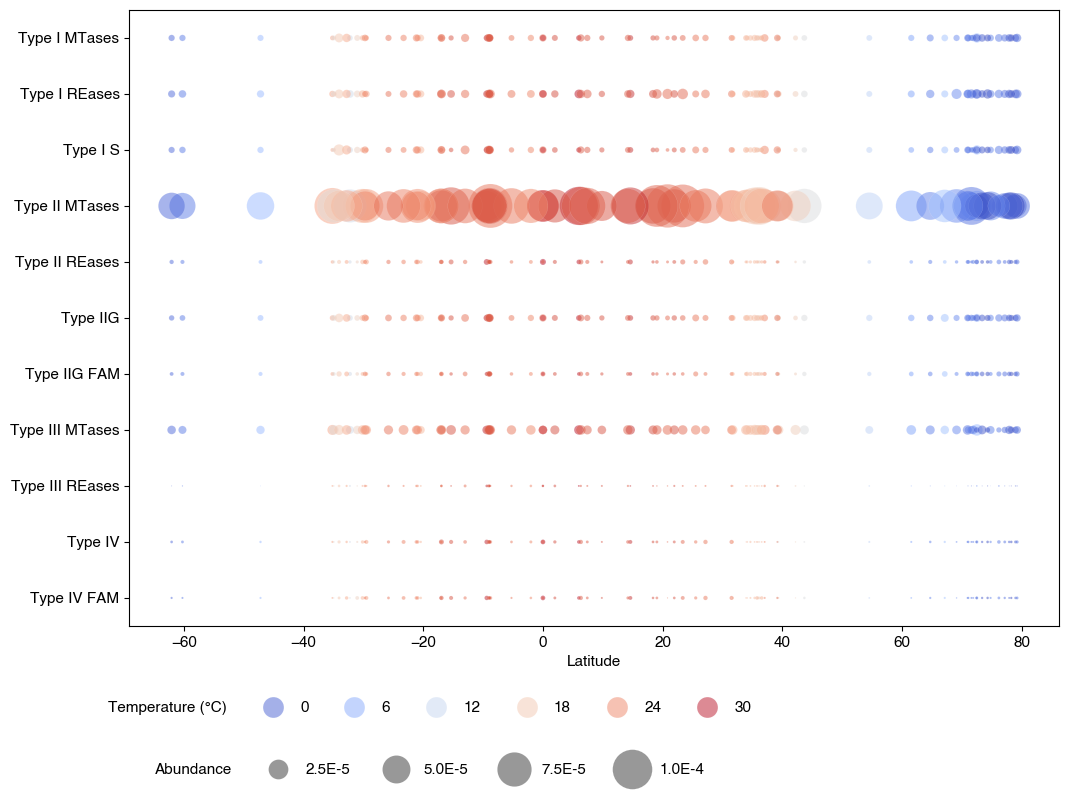

In [4]:
plt.rcParams.update({'font.family': 'Helvetica', 'font.size': 11})

plt.figure(figsize=(12, 8))
scatterplot = sns.scatterplot(data=srf_final_df,
                              x='latitude',
                              y='gene_cluster',
                              size='abundance_sum',
                              hue='Temperature (°C)',
                              palette='coolwarm',
                              sizes=(0.1, 1000),
                              alpha=0.5)
plt.xlabel('Latitude')
plt.ylabel('')

# Get handles (order assumed: first for hue then for size)
handles, _ = scatterplot.get_legend_handles_labels()
# New labels as specified
new_labels = ['Temperature (°C)', '0', '6', '12', '18', '24', '30',
              'Abundance', '2.5E-5', '5.0E-5', '7.5E-5', '1.0E-4', '1.25E-4']

# Split handles and labels: first 7 for Temperature, remaining 6 for Abundance.
temp_handles = handles[:7]
size_handles = handles[7:]
temp_labels = new_labels[:7]
size_labels = new_labels[7:]

# Create the first legend (Temperature) at the bottom with larger markers
leg1 = plt.legend(temp_handles, temp_labels, loc='upper center', 
                  bbox_to_anchor=(0.3, -0.1), ncol=7, frameon=False,
                  markerscale=2.5)  # This makes the temperature markers larger
plt.gca().add_artist(leg1)

# Create the second legend (Abundance) below the first
plt.legend(size_handles, size_labels, loc='upper center', 
           bbox_to_anchor=(0.3, -0.2), ncol=6, frameon=False)

#plt.savefig('gene_abundance_plot.pdf', bbox_inches='tight')
#plt.savefig('gene_abundance_plot.svg', bbox_inches='tight')
plt.show()


In [5]:
import sys

def clean_hmm_name(hmm_filename):
    """Cleans the HMM filename to create a gene cluster name."""
    # Remove .hmm extension
    name = hmm_filename.replace(".hmm", "")
    return name

def process_data(input_csv_path):
    """
    Loads analysis results and metadata, processes, and merges them.

    Args:
        input_csv_path (str): Path to the analysis results CSV.

    Returns:
        pandas.DataFrame: Processed DataFrame ready for plotting, or None if error.
    """
    # --- 1. Load Analysis Results ---
    try:
        print(f"Loading analysis results from: {input_csv_path}")
        df_results = pd.read_csv(input_csv_path)
        print(f"  Loaded {len(df_results)} rows.")
        if df_results.empty:
            print("  Warning: Input CSV is empty.")
            return None
    except FileNotFoundError:
        print(f"Error: Input CSV file not found at {input_csv_path}", file=sys.stderr)
        return None
    except pd.errors.EmptyDataError:
        print(f"Error: Input CSV file is empty: {input_csv_path}", file=sys.stderr)
        return None
    except Exception as e:
        print(f"Error loading input CSV {input_csv_path}: {e}", file=sys.stderr)
        return None

    # Identify sample columns (all columns after 'E-value')
    id_vars = ['HMM', 'Hit_Protein_ID', 'Genomic_Location', 'E-value']
    sample_cols = [col for col in df_results.columns if col not in id_vars]

    if not sample_cols:
        print("Error: Could not identify sample columns in the input CSV.", file=sys.stderr)
        print(f"  Expected columns like 'Sample1', 'Sample2', etc. Found columns: {df_results.columns.tolist()}", file=sys.stderr)
        return None

    print(f"  Identified sample columns: {sample_cols}")

    # --- 2. Melt DataFrame ---
    print("Melting DataFrame to long format...")
    df_long = pd.melt(df_results,
                      id_vars=id_vars,
                      value_vars=sample_cols,
                      var_name='sample_ID',
                      value_name='Percentage')
    print(f"  DataFrame melted. New shape: {df_long.shape}")

    # Convert Percentage to numeric, coercing errors to NaN
    df_long['Percentage'] = pd.to_numeric(df_long['Percentage'], errors='coerce')


    # --- 3. Derive gene_cluster ---
    print("Deriving gene_cluster names from HMM filenames...")
    df_long['gene_cluster'] = df_long['HMM'].apply(clean_hmm_name).apply(get_gene_category)

    # --- 4. Calculate Mean Abundance per Cluster per Sample ---
    print("Calculating mean percentage per gene cluster per sample...")
    df_aggregated = df_long.groupby(['gene_cluster', 'sample_ID'])['Percentage'].mean().reset_index()
    # Rename to match plotting code variable name
    df_aggregated.rename(columns={'Percentage': 'abundance_sum'}, inplace=True)
    print(f"  Aggregation complete. Shape: {df_aggregated.shape}")

    return df_aggregated


# Process the data
my_data = process_data("my_abundance.csv")

# Set temperature and latitude columns
my_data['Temperature (°C)'] = -5
my_data['latitude'] = 82

my_data
srf_final_df

Loading analysis results from: my_abundance.csv
  Loaded 3309 rows.
  Identified sample columns: ['barcode01', 'barcode02', 'barcode03', 'barcode05', 'barcode06', 'barcode07', 'barcode08', 'barcode09', 'barcode10', 'barcode11', 'barcode12', 'barcode13', 'barcode14', 'control_barcode04']
Melting DataFrame to long format...
  DataFrame melted. New shape: (46326, 6)
Deriving gene_cluster names from HMM filenames...
Calculating mean percentage per gene cluster per sample...
  Aggregation complete. Shape: (154, 3)


,sample_ID,gene_cluster,abundance_sum,latitude,Temperature (°C)
0,TARA_A100000164,Type I MTases,0.000147,35.7590,21.48665
1,TARA_A100000164,Type I REases,0.000290,35.7590,21.48665
2,TARA_A100000164,Type I S,0.000139,35.7590,21.48665
3,TARA_A100000164,Type II MTases,0.006089,35.7590,21.48665
4,TARA_A100000164,Type II REases,0.000057,35.7590,21.48665
...,...,...,...,...,...
908,TARA_X000000950,Type IIG FAM,0.000093,39.1633,24.48280
909,TARA_X000000950,Type III MTases,0.000439,39.1633,24.48280
910,TARA_X000000950,Type III REases,0.000033,39.1633,24.48280
911,TARA_X000000950,Type IV,0.000021,39.1633,24.48280


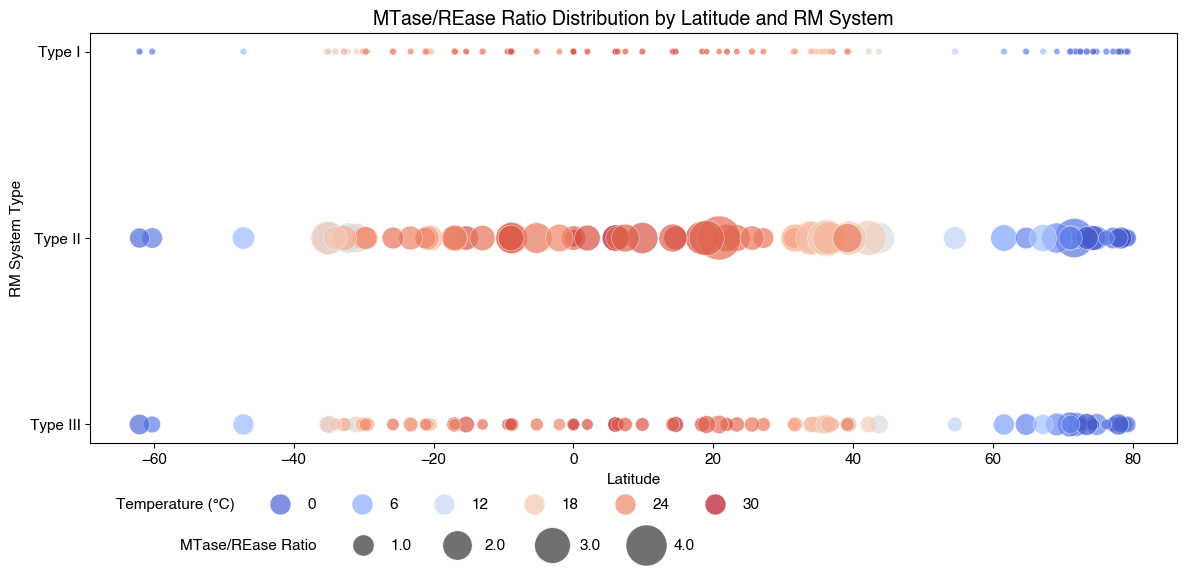

In [6]:
# Function to calculate MTase/REase ratio for each sample
def calculate_sample_ratios(df, type_pairs):
    ratio_data = []
    
    for type_name, (mtase_cluster, rease_cluster) in type_pairs.items():
        # Get data for each cluster type
        mtase_data = df[df['gene_cluster'] == mtase_cluster]
        rease_data = df[df['gene_cluster'] == rease_cluster]
        
        # Find common samples
        common_samples = pd.merge(
            mtase_data[['sample_ID', 'latitude', 'abundance_sum', 'Temperature (°C)']],
            rease_data[['sample_ID', 'abundance_sum']],
            on='sample_ID',
            suffixes=('_mtase', '_rease')
        )
        
        # Calculate ratio for each sample
        common_samples['ratio'] = common_samples['abundance_sum_mtase'] / common_samples['abundance_sum_rease']
        common_samples['rm_type'] = type_name
        
        # Add to our data collection
        ratio_data.append(common_samples[['sample_ID', 'latitude', 'Temperature (°C)', 'rm_type', 'ratio']])
    
    # Combine all data
    if ratio_data:
        return pd.concat(ratio_data)
    else:
        return pd.DataFrame()

# Define the type pairs to compare
type_pairs = {
    "Type I": ("Type I MTases", "Type I REases"),
    "Type II": ("Type II MTases", "Type II REases"),
    "Type III": ("Type III MTases", "Type III REases")
}

# Calculate ratios for all samples
ratio_df = calculate_sample_ratios(srf_final_df, type_pairs)

# Create the plot
plt.rcParams.update({'font.family': 'Helvetica', 'font.size': 11})
plt.figure(figsize=(12, 6))

# Create the scatterplot with ratios
scatterplot = sns.scatterplot(data=ratio_df,
                             x='latitude',
                             y='rm_type',
                             size='ratio',
                             hue='Temperature (°C)',
                             palette='coolwarm',
                             sizes=(20, 1000),
                             alpha=0.7)

plt.xlabel('Latitude')
plt.ylabel('RM System Type')
plt.title('MTase/REase Ratio Distribution by Latitude and RM System', fontsize=14)

# Get handles for legend
handles, labels = scatterplot.get_legend_handles_labels()

# Define new custom labels
temp_labels = ['Temperature (°C)', '0', '6', '12', '18', '24', '30']
ratio_labels = ['MTase/REase Ratio', '1.0', '2.0', '3.0', '4.0', '5.0']

# Split handles appropriately
temp_handles = handles[:7]
ratio_handles = handles[7:]

# Create the first legend (Temperature) at the bottom with larger markers
leg1 = plt.legend(temp_handles, temp_labels, loc='upper center', 
                 bbox_to_anchor=(0.3, -0.1), ncol=7, frameon=False,
                 markerscale=2.5)

plt.gca().add_artist(leg1)

# Create the second legend (Ratio) below the first
plt.legend(ratio_handles, ratio_labels, loc='upper center', 
          bbox_to_anchor=(0.3, -0.2), ncol=6, frameon=False)

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)  # Make room for the legends


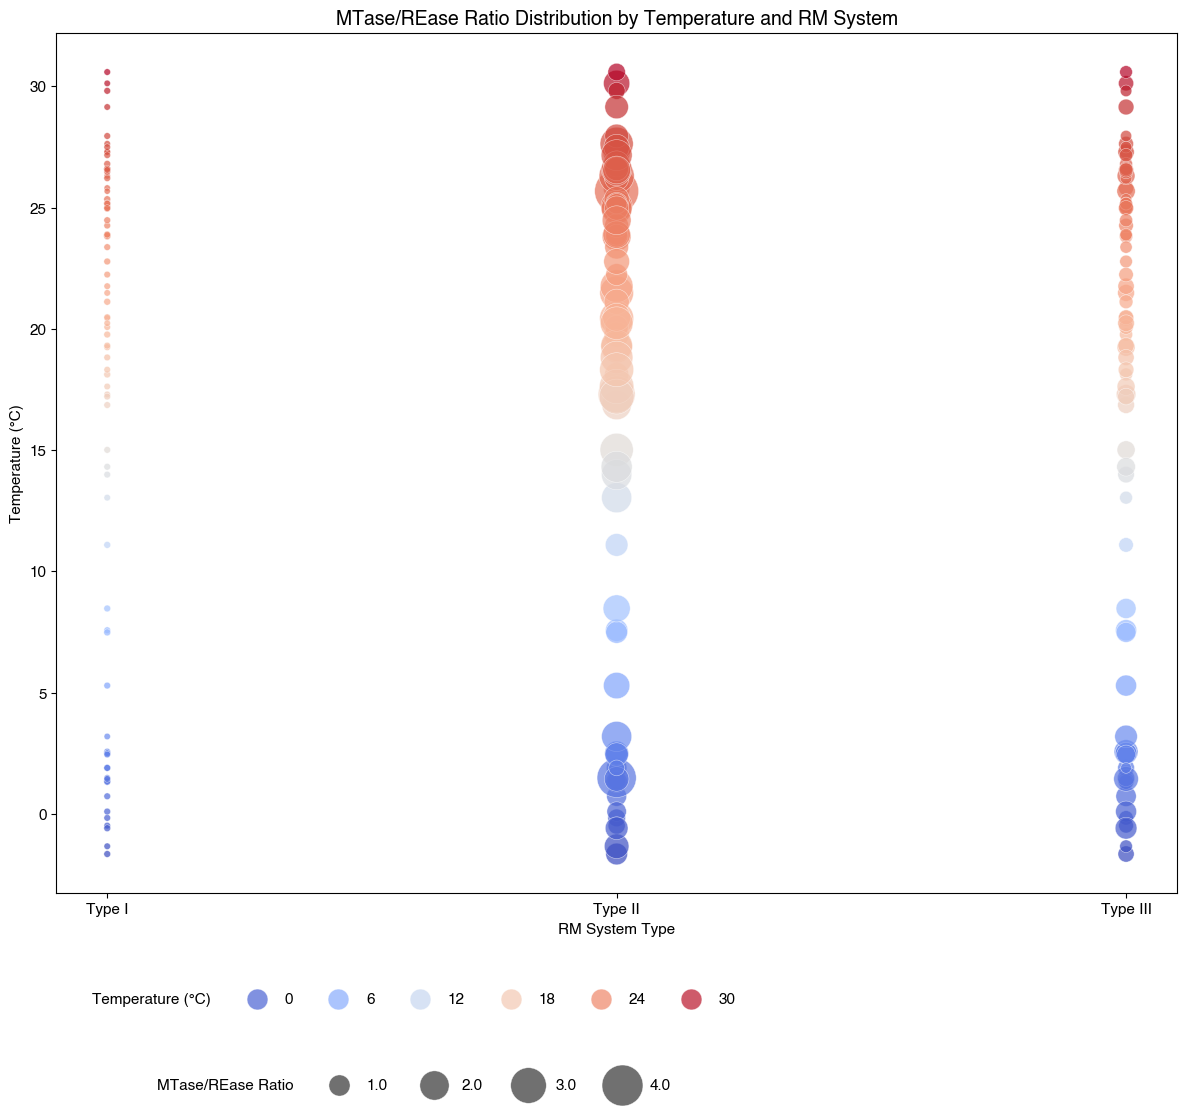

In [7]:
ratio_df = ratio_df.reset_index(drop=True)

# Create the scatterplot with ratios
plt.figure(figsize=(12, 12))
scatterplot = sns.scatterplot(data=ratio_df,
                             x='rm_type',
                             y='Temperature (°C)',
                             size='ratio',
                             hue='Temperature (°C)',
                             palette='coolwarm',
                             sizes=(20, 1000),
                             alpha=0.7)

plt.xlabel('RM System Type')
plt.ylabel('Temperature (°C)')
plt.title('MTase/REase Ratio Distribution by Temperature and RM System', fontsize=14)

# Get handles for legend
handles, labels = scatterplot.get_legend_handles_labels()

# Define new custom labels
temp_labels = ['Temperature (°C)', '0', '6', '12', '18', '24', '30']
ratio_labels = ['MTase/REase Ratio', '1.0', '2.0', '3.0', '4.0', '5.0']

# Split handles appropriately
temp_handles = handles[:7]
ratio_handles = handles[7:]

# Create the first legend (Temperature) at the bottom with larger markers
leg1 = plt.legend(temp_handles, temp_labels, loc='upper center', 
                 bbox_to_anchor=(0.3, -0.1), ncol=7, frameon=False,
                 markerscale=2.5)

plt.gca().add_artist(leg1)

# Create the second legend (Ratio) below the first
plt.legend(ratio_handles, ratio_labels, loc='upper center', 
          bbox_to_anchor=(0.3, -0.2), ncol=6, frameon=False)

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)  # Make room for the legends